In [12]:
# import packages
import numpy as np
np.random.seed(4)
import matplotlib.pyplot as plt
import seaborn as sns

from itertools import groupby
import pandas as pd

import os
import re
import string

import warnings
warnings.filterwarnings('ignore')

from tqdm import tqdm as tq
tq.pandas() #thanks to https://stackoverflow.com/questions/18603270/progress-indicator-during-pandas-operations

In [14]:
def extractCB():
    countryList = ['Fed','ECB','Japan','Armenia','Australia','Canada','Chile','Colombia','Hungary','Iceland','Indonesia',
                   'Korea','NewZealand','Norway','Peru','Philippines','Poland','Thailand']
    
    generalDir = 'data/'
    df = pd.DataFrame(columns=['country','text','date'])
    
    for country in countryList:
        print('Importing country {}'.format(country))
        cbDir = generalDir + '{}/'.format(country)
        if os.path.exists(cbDir):
            for filename in os.listdir(cbDir):
                # get the directory, also check validity
                # for some reason all the file name has the "._" in front of their name, hence there is a need to adjust
                filename = filename[-12:]
                # print(filename)
                path = os.path.join(cbDir, filename)
                if 'DS_Store' in path:
                    print('Invalid files')
                    continue
                    
                #get the date from filename
                date = '{y}-{m}-{d}'.format(y=filename[:4],m=filename[4:6],d=filename[6:8])

                #get the text
                try:
                    with open(path, 'r', encoding="utf8") as path:
                        text = path.read()
                except:
                    print(path)
                    print(date)
                    continue
                
                #combine
                dum = pd.DataFrame([[country,text,date]], columns = ['country','text','date'])
                df = pd.concat([df, dum])
    return df


# Import raw data (and some clean up)
This part is commented out due to CBRaw.csv file given directly in GitHub to avoid uploading all the individual text files

In [17]:
# df = extractCB()
# print(df.shape)
# df.head()

Importing country Fed
Invalid files
Importing country ECB
Invalid files
data/ECB/20000120.txt
2000-01-20
data/ECB/20000217.txt
2000-02-17
data/ECB/20000316.txt
2000-03-16
data/ECB/20000427.txt
2000-04-27
data/ECB/20000525.txt
2000-05-25
data/ECB/20000621.txt
2000-06-21
data/ECB/20000720.txt
2000-07-20
data/ECB/20000803.txt
2000-08-03
data/ECB/20000831.txt
2000-08-31
data/ECB/20001116.txt
2000-11-16
data/ECB/20001130.txt
2000-11-30
data/ECB/20010104.txt
2001-01-04
data/ECB/20010118.txt
2001-01-18
data/ECB/20010215.txt
2001-02-15
data/ECB/20010315.txt
2001-03-15
data/ECB/20010329.txt
2001-03-29
data/ECB/20010426.txt
2001-04-26
data/ECB/20010523.txt
2001-05-23
data/ECB/20010719.txt
2001-07-19
data/ECB/20010802.txt
2001-08-02
data/ECB/20010913.txt
2001-09-13
data/ECB/20010917.txt
2001-09-17
data/ECB/20010927.txt
2001-09-27
data/ECB/20011025.txt
2001-10-25
data/ECB/20011208.txt
2001-12-08
data/ECB/20020801.txt
2002-08-01
data/ECB/20030731.txt
2003-07-31
data/ECB/20040805.txt
2004-08-05
data

,country,text,date
0,Fed,\nThe Federal Open Market Committee voted toda...,2000-02-02
0,Fed,\nThe Federal Open Market Committee voted toda...,2000-03-21
0,Fed,The Federal Open Market Committee voted today ...,2000-05-16
0,Fed,\nThe Federal Open Market Committee at its mee...,2000-06-28
0,Fed,The Federal Open Market Committee at its meeti...,2000-08-22


In [18]:
# df["date"] = pd.to_datetime(df["date"])
# df.shape

(6358, 3)

In [19]:
# # Find duplicate rows
# duplicates = df.duplicated()

# # Count the number of duplicate rows
# num_duplicates = duplicates.sum()

# print(f"Number of duplicate rows: {num_duplicates}")

# # For some reason, my data itself has a bunch of duplications here already. Need to drop the duplications
# print(df.shape)
# df = df.drop_duplicates(keep='first')
# print(df.shape)


Number of duplicate rows: 2549
(6358, 3)
(3809, 3)


In [20]:
# # Check special character
# def identSpecChar(doc):
#     try:
#         pattern = r'[^a-zA-Z\d\s' + re.escape(string.punctuation) + '’' + ']+'
#         return re.findall(pattern, doc)
#     except:
#         return []
        

In [21]:
# # weird symbols
# df['exceptions'] = df['text'].progress_apply(identSpecChar)


100%|██████████| 3809/3809 [00:00<00:00, 8835.58it/s]


In [22]:
# result0 = set(df['exceptions'].sum())
# print(result0)


{'―', '\xad', '·', '−', '\uf06c', 'ñ', 'Í', 'ł', '¼–', 'á', '½', 'ﬂ', '\u200b\u200b\u200b', '٭٭٭', 'Á', '─', '▪', 'Τ', 'ï¿½', 'ö', 'þ', '\u200b\u200b', '\u200b', '→', 'à', '‑', 'é', '́', 'ú', '¾–', '”', '\uf0a7', 'Ø', '⁄', 'Μο', 'ē', '“', 'í', '„', '‘', '½–', '¾', '․', 'ć', '‒', '●', '・', '⅓', 'ì', '€', '‐', '—', '\u200b\u200b\u200b\u200b\u200b', '´', 'ﬁ', '\uf0a7\uf020', 'ā', '–', '¼', '÷', '•', 'č', '»', 'ó', '±', '\uf0b7'}


In [23]:
# # examine the quetsion marks:
# listCheck = result0
# for i in listCheck:
#     print("example for "+i)
#     dum = df[df['text'].str.contains(i, regex = False)]['text']
#     print(len(dum))
#     pattern = re.compile(r'[\w\s]{0,30}'+re.escape(i)+r'[\w\s]{0,30}')
#     for j in range(min(len(dum),5)):
#         print(pattern.findall(dum.iloc[j]))
#     print("\n")
    

example for ―
1
[' that risk factors still exist―including the resurgence of so']


example for ­
2
['er indicators point to ongoing\xad ']
['\n\n\xadThe effects of the fall in oil']


example for ·
1
['\n·Improvements in the way of liq', '\n·Reduction in the official disc']


example for −
1
[' should be in the interval 1¾ −2¾ per cent in the period to t']


example for 
1
['\n\uf06c These may include ', '\n\uf06c Effectively']


example for ñ
69
['s and the persistence of El Niño can delay the convergence of', 'ntual intensification of El Niño could delay such convergence']
['the greater intensity of El Niño have slowed down convergence', ' El Niño has intensified']
['and a strong presence of El Niño have slowed down convergence']
['and a strong presence of El Niño have slowed down convergence']
['and a strong presence of El Niño have slowed down convergence']


example for Í
1
[' Íslandsbanki']


example for ł
1
['gn exchange rate risk of the złoty at Narodowy Bank Polski an']


ex

In [24]:
# # Most of them are just characters from other country language, but a few are legit web error
# removeList = ['\uf0b7', '\uf06c', '\uf020', '\xad', '\uf0a7', '\u200b', '\uf06c']
# for i in removeList:
#     df['text'] = df['text'].str.replace(i,"",regex=False)

# df['text'] = df['text'].str.replace('ﬂ',"fl",regex=False)
# df['text'] = df['text'].str.replace('ﬁ',"fi",regex=False)
# df['text'] = df['text'].str.replace('Τ',"T",regex=False)
# df['text'] = df['text'].str.replace('Μο',"Mo",regex=False)


In [25]:
# # check again weird symbols
# df['exceptions'] = df['text'].progress_apply(identSpecChar)


100%|██████████| 3809/3809 [00:00<00:00, 9038.82it/s]


In [26]:
# result0 = set(df['exceptions'].sum())
# print(result0)

{'―', '·', '−', 'ñ', 'Í', 'ł', '¼–', 'á', '½', '٭٭٭', 'Á', '─', '▪', 'ï¿½', 'ö', 'þ', '→', 'à', '‑', 'é', '́', 'ú', '¾–', '”', 'Ø', '⁄', 'ē', '“', 'í', '„', '‘', '½–', '¾', '․', 'ć', '‒', '●', '・', '⅓', 'ì', '€', '‐', '—', '´', 'ā', '–', '¼', '÷', '•', 'č', '»', 'ó', '±'}


In [27]:
# df.drop(columns = ['exceptions'], inplace = True)
# df.columns.tolist()

['country', 'text', 'date']

In [28]:
# df.to_csv('CBRaw.csv', date_format='%Y-%m-%d', index = False)


# Create some new variables

In [41]:
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize, sent_tokenize


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lynn\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [42]:
# imported the completed files
df = pd.read_csv('CBRaw.csv', parse_dates = ['date'])


## Basic

In [46]:
def getBasic(doc):
    numSentence = len(sent_tokenize(doc))
    numWords = len(word_tokenize(doc))
    numWordspSentence = numWords/numSentence
    return [numWords, numSentence, numWordspSentence]


In [48]:
# apply
df['basic'] = df['text'].progress_apply(lambda x: getBasic(x))

# separated
basicList = ['numWords', 'numSentence', 'numWordspSentence']
df[basicList] = pd.DataFrame(df.basic.tolist(), index= df.index)
df.drop(columns = ['basic'],inplace=True)
df.head()


100%|██████████| 3809/3809 [00:16<00:00, 232.88it/s]


,country,text,date,numWords,numSentence,numWordspSentence
0,Fed,\nThe Federal Open Market Committee voted toda...,2000-02-02,208,7,29.714286
1,Fed,\nThe Federal Open Market Committee voted toda...,2000-03-21,215,7,30.714286
2,Fed,The Federal Open Market Committee voted today ...,2000-05-16,203,7,29.000000
3,Fed,\nThe Federal Open Market Committee at its mee...,2000-06-28,174,5,34.800000
4,Fed,The Federal Open Market Committee at its meeti...,2000-08-22,174,5,34.800000


## Add policy rate and Export

In [67]:
# df['index1'] = df.index
df['dateym'] = df['date'].dt.to_period('M')
df.head()

,country,text,date,numWords,numSentence,numWordspSentence,dateym
0,Fed,\nThe Federal Open Market Committee voted toda...,2000-02-02,208,7,29.714286,2000-02
0,Fed,\nThe Federal Open Market Committee voted toda...,2000-03-21,215,7,30.714286,2000-03
0,Fed,The Federal Open Market Committee voted today ...,2000-05-16,203,7,29.000000,2000-05
0,Fed,\nThe Federal Open Market Committee at its mee...,2000-06-28,174,5,34.800000,2000-06
0,Fed,The Federal Open Market Committee at its meeti...,2000-08-22,174,5,34.800000,2000-08


In [77]:
dfpolicy = pd.read_excel('CountryVariables/BIS/policyRate.xlsx', sheet_name = 1)
dfpolicy.head()

,DATAFLOW_ID:Dataflow ID,KEY:Timeseries Key,FREQ:Frequency,REF_AREA:Reference area,Unit,Unit multiplier,TIME_PERIOD:Period,OBS_CONF:Confidentiality,OBS_PRE_BREAK:Pre-break value,OBS_STATUS:Status,OBS_VALUE:Value
0,"BIS,WS_CBPOL,1.0",M.AR,M:Monthly,AR:Argentina,Per cent per year,Units,2000-01-31,F:Free,NaN,A:Normal value,7.21
1,"BIS,WS_CBPOL,1.0",M.AR,M:Monthly,AR:Argentina,Per cent per year,Units,2000-02-29,F:Free,NaN,A:Normal value,6.12
2,"BIS,WS_CBPOL,1.0",M.AR,M:Monthly,AR:Argentina,Per cent per year,Units,2000-03-31,F:Free,NaN,A:Normal value,6.37
3,"BIS,WS_CBPOL,1.0",M.AR,M:Monthly,AR:Argentina,Per cent per year,Units,2000-04-30,F:Free,NaN,A:Normal value,6.31
4,"BIS,WS_CBPOL,1.0",M.AR,M:Monthly,AR:Argentina,Per cent per year,Units,2000-05-31,F:Free,NaN,A:Normal value,6.82


In [79]:
print(dfpolicy.columns.tolist())

['DATAFLOW_ID:Dataflow ID', 'KEY:Timeseries Key', 'FREQ:Frequency', 'REF_AREA:Reference area', 'Unit', 'Unit multiplier', 'TIME_PERIOD:Period', 'OBS_CONF:Confidentiality', 'OBS_PRE_BREAK:Pre-break value', 'OBS_STATUS:Status', 'OBS_VALUE:Value']


In [81]:
dfpolicy["TIME_PERIOD:Period"] = pd.to_datetime(dfpolicy["TIME_PERIOD:Period"])
dfpolicy['dateym'] = dfpolicy['TIME_PERIOD:Period'].dt.to_period('M')
dfpolicy['FREQ:Frequency'].value_counts()


FREQ:Frequency
M:Monthly    11374
Name: count, dtype: int64

In [83]:
listCheck = ['KEY:Timeseries Key','Unit', 'Unit multiplier','OBS_CONF:Confidentiality', 'OBS_PRE_BREAK:Pre-break value', 'OBS_STATUS:Status']
for i in listCheck:
    print('For variable '+i)
    print(dfpolicy[i].value_counts())
    print('\n')


For variable KEY:Timeseries Key
KEY:Timeseries Key
M.AR    300
M.IL    300
M.XM    300
M.US    300
M.SE    300
M.RU    300
M.PL    300
M.PH    300
M.NO    300
M.MY    300
M.MX    300
M.MK    300
M.IS    300
M.IN    300
M.ZA    300
M.HU    300
M.BR    300
M.CA    300
M.CH    300
M.CL    300
M.GB    300
M.DK    300
M.CZ    300
M.CN    300
M.CO    299
M.SA    299
M.RS    299
M.KR    299
M.NZ    299
M.HK    299
M.AU    299
M.TH    296
M.MA    287
M.HR    276
M.TR    275
M.RO    264
M.PE    256
M.ID    233
M.JP    194
Name: count, dtype: int64


For variable Unit
Unit
Per cent per year    11374
Name: count, dtype: int64


For variable Unit multiplier
Unit multiplier
Units    11374
Name: count, dtype: int64


For variable OBS_CONF:Confidentiality
OBS_CONF:Confidentiality
F:Free    11374
Name: count, dtype: int64


For variable OBS_PRE_BREAK:Pre-break value
Series([], Name: count, dtype: int64)


For variable OBS_STATUS:Status
OBS_STATUS:Status
A:Normal value                        11321
M:Mi

In [85]:
dfpolicy['REF_AREA:Reference area'].value_counts()

REF_AREA:Reference area
AR:Argentina          300
IL:Israel             300
XM:Euro area          300
US:United States      300
SE:Sweden             300
RU:Russia             300
PL:Poland             300
PH:Philippines        300
NO:Norway             300
MY:Malaysia           300
MX:Mexico             300
MK:North Macedonia    300
IS:Iceland            300
IN:India              300
ZA:South Africa       300
HU:Hungary            300
BR:Brazil             300
CA:Canada             300
CH:Switzerland        300
CL:Chile              300
GB:United Kingdom     300
DK:Denmark            300
CZ:Czechia            300
CN:China              300
CO:Colombia           299
SA:Saudi Arabia       299
RS:Serbia             299
KR:Korea              299
NZ:New Zealand        299
HK:Hong Kong SAR      299
AU:Australia          299
TH:Thailand           296
MA:Morocco            287
HR:Croatia            276
TR:Türkiye            275
RO:Romania            264
PE:Peru               256
ID:Indonesia  

In [87]:
# change the necessary names to the one we have for merging, no armenia
countryList = ['Fed','ECB','Japan','Australia','Canada','Chile','Colombia','Hungary','Iceland','Indonesia',
               'Korea','NewZealand','Norway','Peru','Philippines','Poland','Thailand']
diList = ['US:United States', 'XM:Euro area','JP:Japan','AU:Australia', 'CA:Canada','CL:Chile', 'CO:Colombia',
          'HU:Hungary','IS:Iceland','ID:Indonesia','KR:Korea','NZ:New Zealand','NO:Norway','PE:Peru',
          'PH:Philippines','PL:Poland','TH:Thailand']
di = dict(zip(diList, countryList))
dfpolicy['REF_AREA:Reference area'] = dfpolicy['REF_AREA:Reference area'].map(di).fillna(dfpolicy['REF_AREA:Reference area'])
dfpolicy['REF_AREA:Reference area'].value_counts()
          

REF_AREA:Reference area
AR:Argentina          300
IL:Israel             300
ECB                   300
Fed                   300
SE:Sweden             300
RU:Russia             300
Poland                300
Philippines           300
Norway                300
MY:Malaysia           300
MX:Mexico             300
MK:North Macedonia    300
Iceland               300
IN:India              300
ZA:South Africa       300
Hungary               300
BR:Brazil             300
Canada                300
CH:Switzerland        300
Chile                 300
GB:United Kingdom     300
DK:Denmark            300
CZ:Czechia            300
CN:China              300
Colombia              299
SA:Saudi Arabia       299
RS:Serbia             299
Korea                 299
NewZealand            299
HK:Hong Kong SAR      299
Australia             299
Thailand              296
MA:Morocco            287
HR:Croatia            276
TR:Türkiye            275
RO:Romania            264
Peru                  256
Indonesia     

In [89]:
# Bc there are missing values, thats why not all are 300,  furthermore, there are some missing straight up, but we will worry abt it after merge
dfpolicy.isnull().sum()

DATAFLOW_ID:Dataflow ID              0
KEY:Timeseries Key                   0
FREQ:Frequency                       0
REF_AREA:Reference area              0
Unit                                 0
Unit multiplier                      0
TIME_PERIOD:Period                   0
OBS_CONF:Confidentiality             0
OBS_PRE_BREAK:Pre-break value    11374
OBS_STATUS:Status                    0
OBS_VALUE:Value                     53
dateym                               0
dtype: int64

In [91]:
# now merge based on country and date
print(df.shape)
print(dfpolicy.shape)
dfpolicy = dfpolicy[['REF_AREA:Reference area','dateym','OBS_VALUE:Value']]
dfFinal = pd.merge(df, dfpolicy,
    how='left',
    left_on=['country', 'dateym'],
    right_on=['REF_AREA:Reference area', 'dateym'],
)
dfFinal.head()

(3809, 7)
(11374, 12)


,country,text,date,numWords,numSentence,numWordspSentence,dateym,REF_AREA:Reference area,OBS_VALUE:Value
0,Fed,\nThe Federal Open Market Committee voted toda...,2000-02-02,208,7,29.714286,2000-02,Fed,5.75
1,Fed,\nThe Federal Open Market Committee voted toda...,2000-03-21,215,7,30.714286,2000-03,Fed,6.00
2,Fed,The Federal Open Market Committee voted today ...,2000-05-16,203,7,29.000000,2000-05,Fed,6.50
3,Fed,\nThe Federal Open Market Committee at its mee...,2000-06-28,174,5,34.800000,2000-06,Fed,6.50
4,Fed,The Federal Open Market Committee at its meeti...,2000-08-22,174,5,34.800000,2000-08,Fed,6.50


In [93]:
dfFinal.isnull().sum()

country                      0
text                         0
date                         0
numWords                     0
numSentence                  0
numWordspSentence            0
dateym                       0
REF_AREA:Reference area    305
OBS_VALUE:Value            305
dtype: int64

In [95]:
# the missing value should mainly due to Armenia
dfFinal[dfFinal['country'] == 'Armenia'].isnull().sum()

country                      0
text                         0
date                         0
numWords                     0
numSentence                  0
numWordspSentence            0
dateym                       0
REF_AREA:Reference area    144
OBS_VALUE:Value            144
dtype: int64

In [97]:
dfnull = dfFinal[dfFinal['REF_AREA:Reference area'].isnull()]
dfnull['country'].value_counts()

country
Armenia    144
Japan      130
Peru        31
Name: count, dtype: int64

### Problem with Japan missing values, they dont have it in some period
They are conducting money market operation instead and there are no rate mentioned

As for Peru, all number before 2003-09 does not have value partly because again, it is not clear what is this rate on their statement

In [99]:
print(dfpolicy[dfpolicy['REF_AREA:Reference area']=='Japan'].head())
print(dfpolicy[dfpolicy['REF_AREA:Reference area']=='Japan'].tail())
dfpolicy[dfpolicy['REF_AREA:Reference area']=='Japan'].shape

     REF_AREA:Reference area   dateym  OBS_VALUE:Value
5306                   Japan  2000-08             0.25
5307                   Japan  2000-09             0.25
5308                   Japan  2000-10             0.25
5309                   Japan  2000-11             0.25
5310                   Japan  2000-12             0.25
     REF_AREA:Reference area   dateym  OBS_VALUE:Value
5495                   Japan  2024-08             0.25
5496                   Japan  2024-09             0.25
5497                   Japan  2024-10             0.25
5498                   Japan  2024-11             0.25
5499                   Japan  2024-12             0.25


(194, 3)

In [101]:
print(df[df['country']=='Japan'].head())
print(df[df['country']=='Japan'].tail())
df[df['country']=='Japan'].drop_duplicates(subset=['dateym']).shape

  country                                               text       date  \
0   Japan  At the Monetary Policy Meeting held today, the... 2000-01-17   
0   Japan  At the Monetary Policy Meeting held today, the... 2000-02-10   
0   Japan  At the Monetary Policy Meeting held today, the... 2000-02-24   
0   Japan  At the Monetary Policy Meeting held today, the... 2000-03-08   
0   Japan  At the Monetary Policy Meeting held today, the... 2000-03-24   

   numWords  numSentence  numWordspSentence   dateym  
0        75            2               37.5  2000-01  
0        75            2               37.5  2000-02  
0        75            2               37.5  2000-02  
0        75            2               37.5  2000-03  
0        75            2               37.5  2000-03  
  country                                               text       date  \
0   Japan  At the Monetary Policy Meeting (MPM) held toda... 2024-04-26   
0   Japan  1. At the Monetary Policy Meeting (MPM) held t... 2024-06-

(263, 7)

### Back after 

In [103]:
dfFinal.drop(columns = ['REF_AREA:Reference area'], inplace = True)
dfFinal.rename(columns = {'OBS_VALUE:Value': 'policyRate'}, inplace = True)
dfFinal.head()

,country,text,date,numWords,numSentence,numWordspSentence,dateym,policyRate
0,Fed,\nThe Federal Open Market Committee voted toda...,2000-02-02,208,7,29.714286,2000-02,5.75
1,Fed,\nThe Federal Open Market Committee voted toda...,2000-03-21,215,7,30.714286,2000-03,6.00
2,Fed,The Federal Open Market Committee voted today ...,2000-05-16,203,7,29.000000,2000-05,6.50
3,Fed,\nThe Federal Open Market Committee at its mee...,2000-06-28,174,5,34.800000,2000-06,6.50
4,Fed,The Federal Open Market Committee at its meeti...,2000-08-22,174,5,34.800000,2000-08,6.50


In [105]:
dfFinal.to_csv('CB.csv', date_format='%Y-%m-%d', index = False)


# Textual characteristics extractions

## (outdated) Topic modelling (later replaced by notebook 03)
Hence there is no need to run this. However, this is left here to show why in later notebooks or later part of this notebook, some variables are there and is replaced

In [26]:
# import re
# import numpy as np
# import pandas as pd
# from pprint import pprint

# # Gensim
# import gensim
# import gensim.corpora as corpora
# from gensim.utils import simple_preprocess
# from gensim.models import CoherenceModel

# # spacy for lemmatization
# import spacy

# # Plotting tools
# import pyLDAvis
# import pyLDAvis.gensim  # don't skip this
# import matplotlib.pyplot as plt
# %matplotlib inline

# # Enable logging for gensim - optional
# import logging
# logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.ERROR)

# import warnings
# warnings.filterwarnings("ignore",category=DeprecationWarning)


In [117]:
# df = pd.read_csv('CB.csv', parse_dates = ['date'])
# print(df.columns.tolist())
# df.shape


['country', 'text', 'date', 'numWords', 'numSentence', 'numWordspSentence', 'dateym', 'policyRate']


(3809, 8)

In [36]:
# # NLTK Stop words
# from nltk.corpus import stopwords
# stop_words = stopwords.words('english')
# extendList = ['committee', 'federal', 'fomc', 'euro', 'area', 'council', 'bank', 'japan', 'yen', 'trillion', 'month', 'months', 
#               'armenia', 'cba', 'board', 'australia', 'australian', 'year', 'canada', 'canadian', 'chile', 'monthly', 'tes',
#               'central', 'meeting', 'colombia', 'banco','republica','directors', 'hungarian', 'hungary', 'iceland', 'mpc', 'day', 'term', 
#               'indonesia', 'rupiah', 'yoy', 'korea', 'korean','seoul', 'norway', 'norges', 'executive', 'norwegian', 'peru', 'bcrp', 
#               'million', 'annual', 'philippines', 'bsp', 'poland', 'nbp', 'polish', 'thailand', 'thai','bdr', 'bdbr', 'usd', 'rp', 
#               'us','usd','eu', 'ii', 'united','states', 'zloty', 'iii', 'iv','v','vi', "china",'lombard',
#               'percent','per','cent','billion', 'quarter','january', 'february', 'march', 'april', 'may', 'june', 'july', 
#               'august', 'september', 'october', 'november','december']
# stop_words.extend(extendList)


In [37]:
# # Convert to list
# data = df.text.values.tolist()

# # Remove Emails
# data = [re.sub('\S*@\S*\s?', '', sent) for sent in data]

# # Remove new line characters
# data = [re.sub('\s+', ' ', sent) for sent in data]

# # Remove distracting single quotes
# data = [re.sub("\'", "", sent) for sent in data]

# pprint(data[:1])


[' The Federal Open Market Committee voted today to raise its target for the '
 'federal funds rate by 25 basis points to 5-3/4 percent. In a related action, '
 'the Board of Governors approved a 25 basis point increase in the discount '
 'rate to 5-1/4 percent. The Committee remains concerned that over time '
 'increases in demand will continue to exceed the growth in potential supply, '
 'even after taking account of the pronounced rise in productivity growth. '
 'Such trends could foster inflationary imbalances that would undermine the '
 'economys record economic expansion. Against the background of its long-run '
 'goals of price stability and sustainable economic growth and of the '
 'information currently available, the Committee believes the risks are '
 'weighted mainly toward conditions that may generate heightened inflation '
 'pressures in the foreseeable future. In taking the discount rate action, the '
 'Federal Reserve Board approved requests submitted by the Boards of D

In [38]:
# def sent_to_words(sentences):
#     for sentence in sentences:
#         yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))  # deacc=True removes punctuations

# data_words = list(sent_to_words(data))

# print(data_words[:1])


[['the', 'federal', 'open', 'market', 'committee', 'voted', 'today', 'to', 'raise', 'its', 'target', 'for', 'the', 'federal', 'funds', 'rate', 'by', 'basis', 'points', 'to', 'percent', 'in', 'related', 'action', 'the', 'board', 'of', 'governors', 'approved', 'basis', 'point', 'increase', 'in', 'the', 'discount', 'rate', 'to', 'percent', 'the', 'committee', 'remains', 'concerned', 'that', 'over', 'time', 'increases', 'in', 'demand', 'will', 'continue', 'to', 'exceed', 'the', 'growth', 'in', 'potential', 'supply', 'even', 'after', 'taking', 'account', 'of', 'the', 'pronounced', 'rise', 'in', 'productivity', 'growth', 'such', 'trends', 'could', 'foster', 'inflationary', 'imbalances', 'that', 'would', 'undermine', 'the', 'economys', 'record', 'economic', 'expansion', 'against', 'the', 'background', 'of', 'its', 'long', 'run', 'goals', 'of', 'price', 'stability', 'and', 'sustainable', 'economic', 'growth', 'and', 'of', 'the', 'information', 'currently', 'available', 'the', 'committee', 'bel

In [40]:
# # Build the bigram and trigram models
# bigram = gensim.models.Phrases(data_words, min_count=5, threshold=100) # higher threshold fewer phrases.
# # trigram = gensim.models.Phrases(bigram[data_words], threshold=100)  

# # Faster way to get a sentence clubbed as a trigram/bigram
# bigram_mod = gensim.models.phrases.Phraser(bigram)
# # trigram_mod = gensim.models.phrases.Phraser(trigram)

# # # See trigram example
# # print(trigram_mod[bigram_mod[data_words[0]]])


In [41]:
# # Define functions for stopwords, bigrams, trigrams and lemmatization
# def remove_stopwords(texts):
#     return [[word for word in simple_preprocess(str(doc)) if word not in stop_words] for doc in texts]

# def make_bigrams(texts):
#     return [bigram_mod[doc] for doc in texts]

# def make_trigrams(texts):
#     return [trigram_mod[bigram_mod[doc]] for doc in texts]

# def lemmatization(texts, tagLimit = False, allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV','PROPN']):
#     """https://spacy.io/api/annotation"""
#     texts_out = []
#     for sent in texts:
#         doc = nlp(" ".join(sent)) 
#         if tagLimit:
#         #This is with tag limit
#             texts_out.append([token.lemma_ for token in doc if token.pos_ in allowed_postags])
#         else:
#         #This is without tag limit
#             texts_out.append([token.lemma_ for token in doc])
# #         #This is no lemma but with tag limit
# #         texts_out.append([token.text for token in doc if token.pos_ in allowed_postags])
#     return texts_out

# # #Add negation if it is a negated word: https://stackoverflow.com/questions/29374157/negation-handling-in-sentiment-analysis
# # def word_is_negated(word):
# #     """ """
    
# #     for child in word.children:
# #         if child.dep_ == 'neg':
# #             return True

# #     if word.pos_ in {'VERB'}:
# #         for ancestor in word.ancestors:
# #             if ancestor.pos_ in {'VERB'}:
# #                 for child2 in ancestor.children:
# #                     if child2.dep_ == 'neg':
# #                         return True

# #     return False

# # def find_negated_wordSentIdxs_in_sent(sent, idxs_of_interest=None):
# #     """ """

# #     negated_word_idxs = set()
# #     for word_sent_idx, word in enumerate(sent):
# #         if idxs_of_interest:
# #             if word_sent_idx not in idxs_of_interest:
# #                 continue
# #         if word_is_negated(word):
# #             negated_word_idxs.add(word_sent_idx)

# #     return negated_word_idxs

# # #entity recognition is in NER of spacy: https://www.analyticsvidhya.com/blog/2021/06/nlp-application-named-entity-recognition-ner-in-python-with-spacy/




In [42]:
# # Remove Stop Words
# data_words_nostops = remove_stopwords(data_words)

# # Form Bigrams
# data_words_bigrams = make_bigrams(data_words_nostops)


In [43]:
# # Initialize spacy 'en' model, keeping only tagger component (for efficiency)
# # python3 -m spacy download en
# nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])
# # nlp.max_length = 4000000

# # Do all with no tag limit
# data_lemmatized = lemmatization(data_words_bigrams, tagLimit = False)

# # # Do lemmatization + 2-grams keeping only noun, adj, vb, adv, propn
# # data_lemmatized = lemmatization(data_words_bigrams, tagLimit = True, allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV','PROPN'])


In [46]:
# # Create Dictionary 
# id2word = corpora.Dictionary(data_lemmatized)  
# # Create Corpus 
# texts = data_lemmatized  
# # Term Document Frequency 
# corpus = [id2word.doc2bow(text) for text in texts]  


In [49]:
# import pickle

# with open("LDA/ldaComponents/corpus.pkl", "wb") as f: # "wb" because we want to write in binary mode
#     pickle.dump(corpus, f)
    
# with open("LDA/ldaComponents/id2word.pkl", "wb") as f: # "wb" because we want to write in binary mode
#     pickle.dump(id2word, f)

# with open("LDA/ldaComponents/data_lemmatized.pkl", "wb") as f: # "wb" because we want to write in binary mode
#     pickle.dump(data_lemmatized, f)


In [50]:
# import pickle
# with open("LDA/ldaComponents/corpus.pkl", "rb") as f: 
#     corpus = pickle.load(f)

# with open("LDA/ldaComponents/id2word.pkl", "rb") as f: # "rb" because we want to read in binary mode
#     id2word = pickle.load(f)

# with open("LDA/ldaComponents/data_lemmatized.pkl", "rb") as f: # "rb" because we want to read in binary mode
#     data_lemmatized = pickle.load(f)
    

In [51]:
# # supporting function
# def compute_coherence_values(corpus, dictionary, k, a, b):
    
#     lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus,
#                                            id2word=dictionary,
#                                            num_topics=k, 
#                                            random_state=50,
#                                            update_every=1,
#                                            chunksize=100,
#                                            passes=10,
#                                            alpha=a,
#                                            eta=b)
    
#     coherence_model_lda = CoherenceModel(model=lda_model, texts=data_lemmatized, dictionary=id2word, coherence='c_v')
    
#     return [coherence_model_lda.get_coherence(), lda_model.log_perplexity(corpus)]
    

- Alpha and Beta are Hyperparameters — alpha represents document-topic density and Beta represents topic-word density, chunksize is the number of documents to be used in each training chunk, update_every determines how often the model parameters should be updated and passes is the total number of training passes.

- A measure for best number of topics really depends on kind of corpus you are using, the size of corpus, number of topics you expect to see.

Another way to look at this:

- Number of Topics (K)
- Dirichlet hyperparameter alpha: Document-Topic Density
- Dirichlet hyperparameter beta: Word-Topic Density

On how to choose the number of topic
- Coherence score and perplexity provide a convinent way to measure how good a given topic model is.
- Lower the perplexity better the model.
- Higher the topic coherence, the topic is more human interpretable.

In [53]:
# grid = {}
# grid['Validation_Set'] = {}

# # Topics range
# min_topics = 5
# max_topics = 30
# step_size = 1
# topics_range = range(min_topics, max_topics, step_size)

# # Validation sets
# num_of_docs = len(corpus)
# corpus_sets = [corpus]

# corpus_title = ['100% Corpus']

# model_results = {'Validation_Set': [],
#                  'Topics': [],
#                  'Alpha': [],
#                  'Beta': [],
#                  'Coherence': [],
#                  'Perplexity': []
#                 }


# # iterate through validation corpuses
# for i in range(len(corpus_sets)):
#     # iterate through number of topics
#     for k in topics_range:
#         alpha = 1/k
#         eta = 1/k
#         # get the coherence score for the given parameters
#         cv = compute_coherence_values(corpus=corpus_sets[i], dictionary=id2word, 
#                                       k=k, a=alpha, b=eta)
#         # Save the model results
#         model_results['Validation_Set'].append(corpus_title[i])
#         model_results['Topics'].append(k)
#         model_results['Alpha'].append(alpha)
#         model_results['Beta'].append(eta)
#         model_results['Coherence'].append(cv[0])
#         model_results['Perplexity'].append(cv[1])


# pd.DataFrame(model_results).to_csv('LDA/ldaDict/lda.csv', index=False)
    

In [54]:
# dflda = pd.read_csv('LDA/ldaDict/lda.csv')
# dflda


,Validation_Set,Topics,Alpha,Beta,Coherence,Perplexity
0,100% Corpus,5,0.200000,0.200000,0.337583,-6.687403
1,100% Corpus,6,0.166667,0.166667,0.345764,-6.718327
2,100% Corpus,7,0.142857,0.142857,0.341945,-6.735587
3,100% Corpus,8,0.125000,0.125000,0.377973,-6.796726
4,100% Corpus,9,0.111111,0.111111,0.351424,-6.812848
5,100% Corpus,10,0.100000,0.100000,0.390967,-6.922274
6,100% Corpus,11,0.090909,0.090909,0.381889,-7.094498
7,100% Corpus,12,0.083333,0.083333,0.374502,-7.271987
8,100% Corpus,13,0.076923,0.076923,0.393823,-7.745976
9,100% Corpus,14,0.071429,0.071429,0.408662,-8.281951


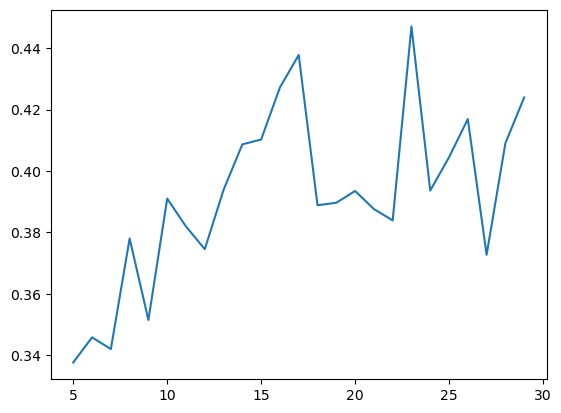

In [55]:
# dflda.sort_values(by=['Topics'], inplace=True)
# plt.plot(dflda['Topics'],dflda['Coherence'])
# plt.show()


In [56]:
# print(dflda[dflda['Coherence'] == max(dflda['Coherence'])])


   Validation_Set  Topics     Alpha      Beta  Coherence  Perplexity
18    100% Corpus      23  0.043478  0.043478   0.447066   -13.59281


In [101]:
# num_topics_list = [7,13,25,27,29]
# for num_topics in num_topics_list:
#     alpha = 1/num_topics
#     eta = 1/num_topics
#     dum = compute_coherence_values(corpus, id2word, num_topics, alpha, eta)
#     new_row = {'Validation_Set':'100% Corpus','Topics':num_topics,
#                'Alpha':alpha,'Beta':eta,
#                'Coherence':dum[0], 'Perplexity':dum[1]}
#     dflda= pd.concat([dflda, pd.DataFrame([new_row])], ignore_index=True)
    

In [102]:
# dflda[dflda['Coherence'] == max(dflda['Coherence'])]


,Validation_Set,Topics,Alpha,Beta,Coherence,Perplexity
23,100% Corpus,13,auto,0.076923,0.444996,-7.42095


In [66]:
# dflda.sort_values(by=['Topics'], inplace=True)
# dflda.to_csv('LDA/ldaDict/lda.csv', index=False)


In [73]:
# # After you have picked a topic hyperparameter: 8 or 15
# num_topics = 10

# lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus,
#                                        id2word=id2word,
#                                        num_topics=num_topics, 
#                                        random_state=50,
#                                        update_every=1,
#                                        chunksize=100,
#                                        passes=10,
#                                        alpha='auto',
#                                        eta=1/num_topics)

In [74]:
# # Visualize the topics
# pyLDAvis.enable_notebook()
# vis = pyLDAvis.gensim.prepare(lda_model, corpus, id2word, mds='mmds')
# vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
5      0.190623  0.272136       1        1  34.553509
1      0.014782  0.324373       2        1  27.130757
6     -0.363596 -0.006151       3        1  22.910049
8     -0.202348  0.348337       4        1   8.862532
9     -0.275284 -0.288250       5        1   3.246167
7     -0.264229  0.151480       6        1   2.433909
3      0.102036 -0.384606       7        1   0.788746
2      0.239653 -0.160055       8        1   0.058550
0      0.294952 -0.129474       9        1   0.014432
4      0.263412 -0.127789      10        1   0.001350, topic_info=          Term          Freq         Total Category  logprob  loglift
40   inflation  30275.000000  30275.000000  Default  30.0000  30.0000
25    economic  18673.000000  18673.000000  Default  29.0000  29.0000
349   recovery   6736.000000   6736.000000  Default  28.0000  28.0000
56        rate  28104.000000  28104.000000  Default  27.0000  27.0000
125     policy  20959.000000  20959.000000  Default  26.0000  26.0000
..         ...           ...           ...      ...      ...      ...
25    economic      0.001833  18673.414734  Topic10  -9.0076  -4.9237
26    economys      0.001833     11.516945  Topic10  -9.0076   2.4673
27        even      0.001833    226.735945  Topic10  -9.0076  -0.5126
28      exceed      0.001833    415.964446  Topic10  -9.0076  -1.1194
29   expansion      0.001833   1246.406936  Topic10  -9.0076  -2.2169

[617 rows x 6 columns], token_table=      Topic      Freq           Term
term                                
208       1  0.960936     accelerate
208       4  0.038405     accelerate
514       3  0.215606  accommodation
514       6  0.781570  accommodation
344       2  0.572378  accommodative
...     ...       ...            ...
143       6  0.020475           well
1737      1  0.999395         within
80        1  0.449920          would
80        2  0.085365          would
80        3  0.464638          would

[781 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[6, 2, 7, 9, 10, 8, 4, 3, 1, 5])

- Each bubble on the left-hand side represents topic. The larger the bubble, the more prevalent or dominant the topic is. Good topic model will be fairly big topics scattered in different quadrants rather than being clustered on one quadrant.
- The model with too many topics will have many overlaps, small sized bubbles clustered in one region of chart.

In [89]:
# num_topics = 10

# with open("LDA/ldaComponents/corpus.pkl", "rb") as f: 
#     corpus = pickle.load(f)

# with open("LDA/ldaComponents/id2word.pkl", "rb") as f: # "rb" because we want to read in binary mode
#     id2word = pickle.load(f)

# with open("LDA/ldaComponents/data_lemmatized.pkl", "rb") as f: # "rb" because we want to read in binary mode
#     data_lemmatized = pickle.load(f)

# lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus,
#                                        id2word=id2word,
#                                        num_topics=num_topics, 
#                                        random_state=50,
#                                        update_every=1,
#                                        chunksize=100,
#                                        passes=10,
#                                        alpha='auto',
#                                        eta=1/num_topics)

# ldaRes = [lda_model[d] for d in corpus]

# ldaResArray = np.zeros([len(ldaRes), num_topics+1])

# for indexi, i in enumerate(ldaRes):
#     for j in i:
#         ldaResArray[indexi, j[0]] = j[1]
#     ldaResArray[indexi,num_topics] = len(data_lemmatized[indexi])

# topicNames = ['topic_'+str(i) for i in range(num_topics)]
# topicNames.append('numTokenConsidered')
# ldaResNested = ldaResArray.tolist()

# dflda = pd.DataFrame(ldaResNested,columns=topicNames)

# dfWithTopic = pd.merge(df, dflda, left_index=True, right_index=True)
    
# df = dfWithTopic

# df['topicVariance'] = 0.0
# for i in range(num_topics):
#     df['topicVariance'] += df['topic_'+str(i)].apply(lambda x: -x * np.log2(x) if x != 0 else 0.0)

# # #If it needs scaling then run the following
# # df['topicVariance'] = df['topicVariance']*df['numTokenConsidered']

# # df = df.drop(columns= ['topic_'+str(i) for i in range(numTopic)])
# # df = df.drop(columns= ['numTokenConsidered'])
# # print(df.columns)
# df.head()

,country,text,date,numWords,numSentence,numWordspSentence,dateym,policyRate,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,numTokenConsidered,topicVariance
0,Fed,\nThe Federal Open Market Committee voted toda...,2000-02-02,208,7,29.714286,2000-02-29,5.75,0.0,0.405030,0.000000,0.0,0.0,0.126231,0.312697,0.00000,0.116673,0.036771,100.0,1.966317
1,Fed,\nThe Federal Open Market Committee voted toda...,2000-03-21,215,7,30.714286,2000-03-31,6.00,0.0,0.396809,0.000000,0.0,0.0,0.134658,0.311061,0.00000,0.115901,0.038918,98.0,1.985318
2,Fed,The Federal Open Market Committee voted today ...,2000-05-16,203,7,29.000000,2000-05-31,6.50,0.0,0.376541,0.000000,0.0,0.0,0.121259,0.309615,0.00000,0.119003,0.071035,99.0,2.059856
3,Fed,\nThe Federal Open Market Committee at its mee...,2000-06-28,174,5,34.800000,2000-06-30,6.50,0.0,0.612038,0.000000,0.0,0.0,0.052729,0.275684,0.03739,0.017085,0.000000,88.0,1.447415
4,Fed,The Federal Open Market Committee at its meeti...,2000-08-22,174,5,34.800000,2000-08-31,6.50,0.0,0.526626,0.010744,0.0,0.0,0.067528,0.371433,0.00000,0.017514,0.000000,87.0,1.452966


In [90]:
# df.to_csv('CBTopic.csv', date_format='%Y-%m-%d', index = False)


## Get other variables form texts such as emotions (positive/negative or more), document distancing, hawkishness, uncertainty

In [125]:
from transformers import pipeline
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from nltk.tokenize import word_tokenize, sent_tokenize


In [127]:
df = pd.read_csv('CB.csv', parse_dates = ['date'])
df['dateym'] = df['date'].dt.to_period('M')
print(df.shape)
df.head()


(3809, 20)


,country,text,date,numWords,numSentence,numWordspSentence,dateym,policyRate,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,numTokenConsidered,topicVariance
0,Fed,\nThe Federal Open Market Committee voted toda...,2000-02-02,208,7,29.714286,2000-02,5.75,0.0,0.405030,0.000000,0.0,0.0,0.126231,0.312697,0.00000,0.116673,0.036771,100.0,1.966317
1,Fed,\nThe Federal Open Market Committee voted toda...,2000-03-21,215,7,30.714286,2000-03,6.00,0.0,0.396809,0.000000,0.0,0.0,0.134658,0.311061,0.00000,0.115901,0.038918,98.0,1.985318
2,Fed,The Federal Open Market Committee voted today ...,2000-05-16,203,7,29.000000,2000-05,6.50,0.0,0.376541,0.000000,0.0,0.0,0.121259,0.309615,0.00000,0.119003,0.071035,99.0,2.059856
3,Fed,\nThe Federal Open Market Committee at its mee...,2000-06-28,174,5,34.800000,2000-06,6.50,0.0,0.612038,0.000000,0.0,0.0,0.052729,0.275684,0.03739,0.017085,0.000000,88.0,1.447415
4,Fed,The Federal Open Market Committee at its meeti...,2000-08-22,174,5,34.800000,2000-08,6.50,0.0,0.526626,0.010744,0.0,0.0,0.067528,0.371433,0.00000,0.017514,0.000000,87.0,1.452966


### Positive/negative

In [164]:
# Positive, negative
# https://huggingface.co/mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis
modelFinance = pipeline("text-classification", model="mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis", top_k=None)


Device set to use cpu


In [172]:
text = 'The stock is crashing. This is a very bad news. How do we deal with this?'
output = modelFinance(text)
print(output)


[[{'label': 'negative', 'score': 0.9980713725090027}, {'label': 'neutral', 'score': 0.0013273762306198478}, {'label': 'positive', 'score': 0.0006013052770867944}]]


In [178]:
positiveFin(text, n=3)

[0.0005545078465729603, 0.5014967077295296, 0.49794877143176564]

In [176]:
def positiveFin(doc, n = 300):
    labels = ['positive','neutral','negative']
    
    # check if the length (number of potential tokens) of the text exceed n:
    if len(word_tokenize(doc)) > n:
        # print("This text is too long")
        
        # This is when there are sentences
        # if it is, we divide it into pieces that is a little larger than 500 (can change this number if the error still there)
        sentList = sent_tokenize(doc)
        sentLen = 0
        sentPara = [""]
        for sent in sentList:
            if sentLen + len(word_tokenize(sent)) < n:
                sentLen += len(word_tokenize(sent))
                sentPara[-1] = " ".join([sentPara[-1], sent])
            else:
                sentLen = len(word_tokenize(sent))
                sentPara.append(sent)
        
        # we loop since there are multiple paragraph for one doc, store them 
        result0 = [0 for i in range(len(labels))]
        for para in sentPara:
            output = modelFinance(para)
            for i in range(len(labels)):
                d = output[0][i]
                for j, emo in enumerate(labels):
                    if d['label'] == emo: 
                        result0[j] += d['score']
        results = [i/len(sentPara) for i in result0]
    else:
        # the doc itself is only a text
        output = modelFinance(doc)
        results = [0 for i in range(len(labels))]
        for i in range(len(labels)):
            d = output[0][i]
            for j, emo in enumerate(labels):
                if d['label'] == emo: 
                    results[j] += d['score']
        
    return results
    

In [180]:
# apply to the statement:
df['sentimentalFin'] = df['text'].progress_apply(lambda x: positiveFin(x, n=300))

# Then expand it out:
labelList = ['positiveFin','neutralFin','negativeFin']
df[labelList] = pd.DataFrame(df.sentimentalFin.tolist(), index= df.index)
df.drop(columns=['sentimentalFin'], inplace=True)
df.head()



100%|██████████| 3809/3809 [16:14<00:00,  3.91it/s]


,country,text,date,numWords,numSentence,numWordspSentence,dateym,policyRate,topic_0,topic_1,...,topic_5,topic_6,topic_7,topic_8,topic_9,numTokenConsidered,topicVariance,positiveFin,neutralFin,negativeFin
0,Fed,\nThe Federal Open Market Committee voted toda...,2000-02-02,208,7,29.714286,2000-02,5.75,0.0,0.405030,...,0.126231,0.312697,0.00000,0.116673,0.036771,100.0,1.966317,0.982616,0.011739,0.005645
1,Fed,\nThe Federal Open Market Committee voted toda...,2000-03-21,215,7,30.714286,2000-03,6.00,0.0,0.396809,...,0.134658,0.311061,0.00000,0.115901,0.038918,98.0,1.985318,0.970094,0.027729,0.002178
2,Fed,The Federal Open Market Committee voted today ...,2000-05-16,203,7,29.000000,2000-05,6.50,0.0,0.376541,...,0.121259,0.309615,0.00000,0.119003,0.071035,99.0,2.059856,0.987600,0.004938,0.007462
3,Fed,\nThe Federal Open Market Committee at its mee...,2000-06-28,174,5,34.800000,2000-06,6.50,0.0,0.612038,...,0.052729,0.275684,0.03739,0.017085,0.000000,88.0,1.447415,0.998125,0.001324,0.000552
4,Fed,The Federal Open Market Committee at its meeti...,2000-08-22,174,5,34.800000,2000-08,6.50,0.0,0.526626,...,0.067528,0.371433,0.00000,0.017514,0.000000,87.0,1.452966,0.949484,0.011973,0.038543


### Uncertainty

In [ ]:
# Uncertainty



### Hawkishness

In [182]:
# hawkishness
import spacy

# Load the SpaCy model
nlp = spacy.load('en_core_web_sm')

# Define vocabularies
list_goal_voca = {"inflation", "growth", "price", "prices", "wages", "employment", "unemployment", "output", "activity", "GDP", "job"}
list_dovish_voca = {"cut", "decrease", "down", "ease", "fall", "reduce", "deflate", "weak", "weaken", "slow", "loss", "slowdown", "decelerate", "mitigate", "contract", "slice", "shave", "trim", "drop"}
list_hawkish_voca = {"increase", "higher", "raise", "rise", "tighten", "strong", "fast", "gain", "hike", "growth", "accelerate", "expand", "surge", "boom", "strengthen", "up", "lift", "climb"}
list_negation_voca = {"not", "no", "never", "hardly", "barely"} # We use instead the empty set to avoid dealing with negation

# list_negation_voca = {} 

# Define n_gram window
N_GRAM = 5

# Lemmatize statements using SpaCy to automatically tag POS before lemmatizations
def lemmatize_statement_spacy(statement):
    if statement is None or not isinstance(statement, str):  # Handle None values and floats
        return ''
    doc = nlp(statement)
    return ' '.join([token.lemma_ for token in doc])

# Compute the sentiment score with n-gram, handling negations and special treatment for 'unemployment'
def compute_FOMC_score(statement):
    statement = statement.replace(',', '').replace('.', '') # To exclude them from context windows
    words_list = statement.split()
    
    nb_dovish_w = 0
    nb_hawkish_w = 0

    for idx, word in enumerate(words_list):
        context_window = words_list[max(0, idx - N_GRAM // 2): idx + N_GRAM // 2 + 1]

        if word in list_goal_voca:
            negation_present = any(neg_word in context_window for neg_word in list_negation_voca)
            
            flag_dovish = False
            flag_hawkish = False

            for subword in context_window:
                if word != 'unemployment' and subword in list_dovish_voca:
                    if negation_present:
                        nb_hawkish_w += 1
                        flag_hawkish = True
                    else:
                        nb_dovish_w += 1
                        flag_dovish = True
                elif word != 'unemployment' and subword in list_hawkish_voca:
                    if negation_present:
                        nb_dovish_w += 1
                        flag_dovish = True
                    else:
                        nb_hawkish_w += 1
                        flag_hawkish = True
                elif word == 'unemployment' and subword in list_dovish_voca:
                    if negation_present:
                        nb_dovish_w += 1
                        flag_dovish = True
                    else: 
                        nb_hawkish_w += 1
                        flag_hawkish = True
                elif word == 'unemployment' and subword in list_hawkish_voca:
                    if negation_present:
                        nb_hawkish_w += 1
                        flag_hawkish = True
                    else: 
                        nb_dovish_w += 1 
                        flag_dovish = True
                else: 
                    pass

            if flag_dovish and flag_hawkish:
                nb_dovish_w -= 1
                nb_hawkish_w -= 1

    if nb_hawkish_w + nb_dovish_w != 0: 
        score = (nb_hawkish_w - nb_dovish_w) / (nb_hawkish_w + nb_dovish_w)
    else:
        score = 0
    return score

# Adds hawkish scores to the dataset with n-gram choice using SpaCy lemmatization
def add_hawkish_score_spacy(df):
    scores = []
    for statement in df['text']:
        lemmatized_statement = lemmatize_statement_spacy(statement)
        score = compute_FOMC_score(lemmatized_statement)
        scores.append(score)
    df['score_hawkish_wNeg'] = scores
    return df



In [184]:
# add_hawkish_score_spacy(df)
add_hawkish_score_spacy(df)
df.head()

,country,text,date,numWords,numSentence,numWordspSentence,dateym,policyRate,topic_0,topic_1,...,topic_6,topic_7,topic_8,topic_9,numTokenConsidered,topicVariance,positiveFin,neutralFin,negativeFin,score_hawkish_wNeg
0,Fed,\nThe Federal Open Market Committee voted toda...,2000-02-02,208,7,29.714286,2000-02,5.75,0.0,0.405030,...,0.312697,0.00000,0.116673,0.036771,100.0,1.966317,0.982616,0.011739,0.005645,1.0
1,Fed,\nThe Federal Open Market Committee voted toda...,2000-03-21,215,7,30.714286,2000-03,6.00,0.0,0.396809,...,0.311061,0.00000,0.115901,0.038918,98.0,1.985318,0.970094,0.027729,0.002178,1.0
2,Fed,The Federal Open Market Committee voted today ...,2000-05-16,203,7,29.000000,2000-05,6.50,0.0,0.376541,...,0.309615,0.00000,0.119003,0.071035,99.0,2.059856,0.987600,0.004938,0.007462,1.0
3,Fed,\nThe Federal Open Market Committee at its mee...,2000-06-28,174,5,34.800000,2000-06,6.50,0.0,0.612038,...,0.275684,0.03739,0.017085,0.000000,88.0,1.447415,0.998125,0.001324,0.000552,0.6
4,Fed,The Federal Open Market Committee at its meeti...,2000-08-22,174,5,34.800000,2000-08,6.50,0.0,0.526626,...,0.371433,0.00000,0.017514,0.000000,87.0,1.452966,0.949484,0.011973,0.038543,0.6


### Central Bank economic agents

In [185]:
modelAgent = pipeline("text-classification", 
                      model="Moritz-Pfeifer/CentralBankRoBERTa-agent-classifier",
                      top_k=None)
modelSentiment = pipeline("text-classification", 
                      model="Moritz-Pfeifer/CentralBankRoBERTa-sentiment-classifier",
                      top_k = None)

# Central bank targets
def AgentClassifier(doc, n = 300):
    labels = ['Financial Sector','Central Bank','Government','Households','Firms']
    
    # check if the length (number of potential tokens) of the text exceed n:
    if len(word_tokenize(doc)) > n:
        # print("This text is too long")
        
        # This is when there are sentences
        # if it is, we divide it into pieces that is a little larger than 500 (can change this number if the error still there)
        sentList = sent_tokenize(doc)
        sentLen = 0
        sentPara = [""]
        for sent in sentList:
            if sentLen + len(word_tokenize(sent)) < n:
                sentLen += len(word_tokenize(sent))
                sentPara[-1] = " ".join([sentPara[-1], sent])
            else:
                sentLen = len(word_tokenize(sent))
                sentPara.append(sent)
        
        # we loop since there are multiple paragraph for one doc, store them 
        result0 = [0 for i in range(len(labels))]
        for para in sentPara:
            output = modelAgent(para)
            for i in range(len(labels)):
                d = output[0][i]
                for j, emo in enumerate(labels):
                    if d['label'] == emo: 
                        result0[j] += d['score']
        results = [i/len(sentPara) for i in result0]
    else:
        # the doc itself is only a text
        output = modelAgent(doc)
        results = [0 for i in range(len(labels))]
        for i in range(len(labels)):
            d = output[0][i]
            for j, emo in enumerate(labels):
                if d['label'] == emo: 
                    results[j] += d['score']
        
    return results

def SentimentClassifier(doc,n =300):
    labels = ['positive','negative']
    # check if the length (number of potential tokens) of the text exceed n:
    if len(word_tokenize(doc)) > n:
        # print("This text is too long")
        
        # This is when there are sentences
        # if it is, we divide it into pieces that is a little larger than 500 (can change this number if the error still there)
        sentList = sent_tokenize(doc)
        sentLen = 0
        sentPara = [""]
        for sent in sentList:
            if sentLen + len(word_tokenize(sent)) < n:
                sentLen += len(word_tokenize(sent))
                sentPara[-1] = " ".join([sentPara[-1], sent])
            else:
                sentLen = len(word_tokenize(sent))
                sentPara.append(sent)
        
        # we loop since there are multiple paragraph for one doc, store them 
        result0 = [0 for i in range(len(labels))]
        for para in sentPara:
            output = modelSentiment(para)
            for i in range(len(labels)):
                d = output[0][i]
                for j, emo in enumerate(labels):
                    if d['label'] == emo: 
                        result0[j] += d['score']
        results = [i/len(sentPara) for i in result0]
    else:
        # the doc itself is only a text
        output = modelSentiment(doc)
        results = [0 for i in range(len(labels))]
        for i in range(len(labels)):
            d = output[0][i]
            for j, emo in enumerate(labels):
                if d['label'] == emo: 
                    results[j] += d['score']
        
    return results


Device set to use cpu
Device set to use cpu


In [186]:
# apply to the statement:
df['AgentScore'] = df['text'].progress_apply(lambda x: AgentClassifier(x, n=300))

# Then expand it out:
agentList = ['Financial Sector','Central Bank','Government','Households','Firms']
df[agentList] = pd.DataFrame(df.AgentScore.tolist(), index= df.index)
df.drop(columns=['AgentScore'], inplace=True)
df.head()


100%|██████████| 3809/3809 [30:25<00:00,  2.09it/s] 


,country,text,date,numWords,numSentence,numWordspSentence,dateym,policyRate,topic_0,topic_1,...,topicVariance,positiveFin,neutralFin,negativeFin,score_hawkish_wNeg,Financial Sector,Central Bank,Government,Households,Firms
0,Fed,\nThe Federal Open Market Committee voted toda...,2000-02-02,208,7,29.714286,2000-02,5.75,0.0,0.405030,...,1.966317,0.982616,0.011739,0.005645,1.0,0.039913,0.915484,0.017338,0.017253,0.010012
1,Fed,\nThe Federal Open Market Committee voted toda...,2000-03-21,215,7,30.714286,2000-03,6.00,0.0,0.396809,...,1.985318,0.970094,0.027729,0.002178,1.0,0.047212,0.915488,0.016253,0.013339,0.007708
2,Fed,The Federal Open Market Committee voted today ...,2000-05-16,203,7,29.000000,2000-05,6.50,0.0,0.376541,...,2.059856,0.987600,0.004938,0.007462,1.0,0.044012,0.907353,0.017386,0.017673,0.013575
3,Fed,\nThe Federal Open Market Committee at its mee...,2000-06-28,174,5,34.800000,2000-06,6.50,0.0,0.612038,...,1.447415,0.998125,0.001324,0.000552,0.6,0.018061,0.114449,0.017763,0.440884,0.408843
4,Fed,The Federal Open Market Committee at its meeti...,2000-08-22,174,5,34.800000,2000-08,6.50,0.0,0.526626,...,1.452966,0.949484,0.011973,0.038543,0.6,0.022357,0.169332,0.019903,0.422091,0.366318


In [187]:
# apply to the statement:
df['SentimentScore'] = df['text'].progress_apply(lambda x: SentimentClassifier(x, n=300))

# Then expand it out:
sentimentList = ['positiveT','negativeT']
df[sentimentList] = pd.DataFrame(df.SentimentScore.tolist(), index= df.index)
df.drop(columns=['SentimentScore'], inplace=True)
df.head()


100%|██████████| 3809/3809 [30:52<00:00,  2.06it/s]  


,country,text,date,numWords,numSentence,numWordspSentence,dateym,policyRate,topic_0,topic_1,...,neutralFin,negativeFin,score_hawkish_wNeg,Financial Sector,Central Bank,Government,Households,Firms,positiveT,negativeT
0,Fed,\nThe Federal Open Market Committee voted toda...,2000-02-02,208,7,29.714286,2000-02,5.75,0.0,0.405030,...,0.011739,0.005645,1.0,0.039913,0.915484,0.017338,0.017253,0.010012,0.176303,0.823697
1,Fed,\nThe Federal Open Market Committee voted toda...,2000-03-21,215,7,30.714286,2000-03,6.00,0.0,0.396809,...,0.027729,0.002178,1.0,0.047212,0.915488,0.016253,0.013339,0.007708,0.200303,0.799697
2,Fed,The Federal Open Market Committee voted today ...,2000-05-16,203,7,29.000000,2000-05,6.50,0.0,0.376541,...,0.004938,0.007462,1.0,0.044012,0.907353,0.017386,0.017673,0.013575,0.157769,0.842231
3,Fed,\nThe Federal Open Market Committee at its mee...,2000-06-28,174,5,34.800000,2000-06,6.50,0.0,0.612038,...,0.001324,0.000552,0.6,0.018061,0.114449,0.017763,0.440884,0.408843,0.156308,0.843692
4,Fed,The Federal Open Market Committee at its meeti...,2000-08-22,174,5,34.800000,2000-08,6.50,0.0,0.526626,...,0.011973,0.038543,0.6,0.022357,0.169332,0.019903,0.422091,0.366318,0.292485,0.707515


### Concreteness

In [196]:
from wordtangible import word_concreteness, avg_text_concreteness, concrete_abstract_ratio

# Get concreteness rating for a single word
print(word_concreteness("apple"))  # Output: 5.0 (highly concrete)

# Calculate average concreteness of a text
text = "The abstract concept of love is as tangible as the apple in your hand."
print(avg_text_concreteness(text))  # Output: ~2.9 (mix of concrete and abstract)

# Get the ratio of concrete to abstract words
print(concrete_abstract_ratio(text))  # Output: ~1.0 (balanced concrete and abstract words)


5.0
2.903333333333333
1.0


In [79]:
# check other options
text = 'The abstract concept of love is as tangible as the apple in your hand.'
print(avg_text_concreteness(text))

text = 'The abstract concept of love is as tangible as the apple in your hand. Apple'
print(avg_text_concreteness(text))

text = 'I have an apple'
print(avg_text_concreteness(text))

text = 'I have an apple which is very sweet'
print(avg_text_concreteness(text))

text = 'I have an apple'
print(avg_text_concreteness(text, only_rated_words = False))

text = 'I have an apple which is very sweet'
print(avg_text_concreteness(text, only_rated_words = False))


2.903333333333333
3.2028571428571424
5.0
4.5
5.0
4.5


In [198]:
def concreteAvg(doc):
    result = avg_text_concreteness(doc)
    if result == 0.0:
        return np.nan
    else: 
        return result

def concreteAvgExtra(doc):
    result = avg_text_concreteness(doc, only_rated_words = False)
    if result == 0.0:
        return np.nan
    else: 
        return result

def concreteRatio(doc):
    result = concrete_abstract_ratio(doc)
    if result == np.inf:
        return 5.0
    else:
        return result


In [199]:
# apply to the statement:
df['concreteness'] = df['text'].progress_apply(lambda x: concreteAvg(x))
df['concretenessExtra'] = df['text'].progress_apply(lambda x: concreteAvgExtra(x))
df['concreteRatio'] = df['text'].progress_apply(lambda x: concreteRatio(x))

# Then expand it out:
df.head()


100%|██████████| 3809/3809 [00:11<00:00, 327.28it/s]


,country,text,date,numWords,numSentence,numWordspSentence,dateym,policyRate,topic_0,topic_1,...,Financial Sector,Central Bank,Government,Households,Firms,positiveT,negativeT,concreteness,concretenessExtra,concreteRatio
0,Fed,\nThe Federal Open Market Committee voted toda...,2000-02-02,208,7,29.714286,2000-02,5.75,0.0,0.405030,...,0.039913,0.915484,0.017338,0.017253,0.010012,0.176303,0.823697,2.775057,2.028824,1.000000
1,Fed,\nThe Federal Open Market Committee voted toda...,2000-03-21,215,7,30.714286,2000-03,6.00,0.0,0.396809,...,0.047212,0.915488,0.016253,0.013339,0.007708,0.200303,0.799697,2.766706,1.959750,1.000000
2,Fed,The Federal Open Market Committee voted today ...,2000-05-16,203,7,29.000000,2000-05,6.50,0.0,0.376541,...,0.044012,0.907353,0.017386,0.017673,0.013575,0.157769,0.842231,2.694353,2.026726,0.571429
3,Fed,\nThe Federal Open Market Committee at its mee...,2000-06-28,174,5,34.800000,2000-06,6.50,0.0,0.612038,...,0.018061,0.114449,0.017763,0.440884,0.408843,0.156308,0.843692,2.723902,2.302680,0.500000
4,Fed,The Federal Open Market Committee at its meeti...,2000-08-22,174,5,34.800000,2000-08,6.50,0.0,0.526626,...,0.022357,0.169332,0.019903,0.422091,0.366318,0.292485,0.707515,2.784444,2.374105,0.615385


In [201]:
# now deal with the nan on the average concrete
df['concreteMean'] = df['concreteness']
df['concrete25'] = df['concreteness']
df['concreteMean'].fillna(df['concreteMean'].mean(), inplace = True)
df['concrete25'].fillna(2.5, inplace = True)

df['concreteMeanExtra'] = df['concretenessExtra']
df['concrete25Extra'] = df['concretenessExtra']
df['concreteMeanExtra'].fillna(df['concreteMeanExtra'].mean(), inplace = True)
df['concrete25Extra'].fillna(2.5, inplace = True)

df[['country','date','concreteness','concreteMean','concrete25','concretenessExtra','concreteMeanExtra','concrete25Extra']].head(10)


,country,date,concreteness,concreteMean,concrete25,concretenessExtra,concreteMeanExtra,concrete25Extra
0,Fed,2000-02-02,2.775057,2.775057,2.775057,2.028824,2.028824,2.028824
1,Fed,2000-03-21,2.766706,2.766706,2.766706,1.959750,1.959750,1.959750
2,Fed,2000-05-16,2.694353,2.694353,2.694353,2.026726,2.026726,2.026726
3,Fed,2000-06-28,2.723902,2.723902,2.723902,2.302680,2.302680,2.302680
4,Fed,2000-08-22,2.784444,2.784444,2.784444,2.374105,2.374105,2.374105
5,Fed,2000-10-03,2.712500,2.712500,2.712500,2.251887,2.251887,2.251887
6,Fed,2000-11-15,2.701954,2.701954,2.701954,2.260288,2.260288,2.260288
7,Fed,2000-12-19,2.757857,2.757857,2.757857,2.244767,2.244767,2.244767
8,Fed,2001-01-31,2.869292,2.869292,2.869292,2.133092,2.133092,2.133092
9,Fed,2001-03-20,2.652857,2.652857,2.652857,2.137554,2.137554,2.137554


### Looking for others

### Export

In [202]:
print(df.columns.tolist())

['country', 'text', 'date', 'numWords', 'numSentence', 'numWordspSentence', 'dateym', 'policyRate', 'topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'topic_5', 'topic_6', 'topic_7', 'topic_8', 'topic_9', 'numTokenConsidered', 'topicVariance', 'positiveFin', 'neutralFin', 'negativeFin', 'score_hawkish_wNeg', 'Financial Sector', 'Central Bank', 'Government', 'Households', 'Firms', 'positiveT', 'negativeT', 'concreteness', 'concretenessExtra', 'concreteRatio', 'concreteMean', 'concrete25', 'concreteMeanExtra', 'concrete25Extra']


In [208]:
df.to_csv('CB2.csv', date_format='%Y-%m-%d', index = False)


## Find document relevance ==> semantic search

There are so many things, and most of them are spontaneous, I am not sure
- There is using tfidf
- using cosine similarity
- vectorize document using word2vec/glove/bert and then i supposed compare with keywords?
- lbl2vec, is a strange one that needs to be retrained
- ...

From what the document said (see https://www.sbert.net/examples/applications/semantic-search/README.html and https://www.sbert.net/docs/pretrained-models/msmarco-v5.html), our task falls into the problem of short query in a vast and large passages (policy statements). Hence it will be an asymmetric search.

Furthermore, we use the sentence transformer for dot product which is tuned for a longer passage (there are a total of 10 in their model, and 5 of them are normalized, which is tuned for shorter passage, while the remaining 5 are for dot product. The further reason to use the distil version instead of the others is because its performaces are relatively good compare to the rest, and the only one that it is inferior to is the full bert model, but that one is too heavy to run and the improvement differences might not worth it)

In [179]:
from sentence_transformers import SentenceTransformer, util

modelSemantic = SentenceTransformer("msmarco-distilbert-dot-v5")

query_embedding = modelSemantic.encode("How big is London")
passage_embedding = modelSemantic.encode([
    "London has 9,787,426 inhabitants at the 2011 census",
    "London is known for its financial district",
])

print("Similarity:", util.dot_score(query_embedding, passage_embedding))

# second example to confirm that tensor can be normally converted back to numpy and use as it is (?not sure if scaling is required)
query_embedding = modelSemantic.encode("How big is London")
passage_embedding = modelSemantic.encode([
    "London has 9,787,426 inhabitants at the 2011 census",
    "This thing is big, as far as we know we have these collection at home but for rent"
])

print("Similarity:", util.dot_score(query_embedding, passage_embedding))


Similarity: tensor([[77.3481, 71.5315]])
Similarity: tensor([[77.3481, 66.0597]])


In [187]:
query_embedding = modelSemantic.encode("How big is London")
passage_embedding = modelSemantic.encode([
    "London has 9,787,426 inhabitants at the 2011 census",
    "happy",
    "Very very very long passage Debbie put her hand into the hole, sliding her hand down as far as her arm could reach. She wiggled her fingers hoping to touch something, but all she felt was air. She shifted the weight of her body to try and reach an inch or two more down the hole. Her fingers still touched nothing but air. She nervously peered over the edge. She understood in her mind that the view was supposed to be beautiful, but all she felt was fear. There had always been something about heights that disturbed her, and now she could feel the full force of this unease. She reluctantly crept a little closer with the encouragement of her friends as the fear continued to build. She couldn't help but feel that something horrible was about to happen."
])

dum = util.dot_score(query_embedding, passage_embedding).numpy()
print(dum)
print(dum[0][0])

[[77.34813  64.7509   63.438034]]
77.34813


In [197]:
query_embedding = modelSemantic.encode("how big is London")
passage_embedding = modelSemantic.encode("London has 9,787,426 inhabitants at the 2011 census")

dum = util.dot_score(query_embedding, passage_embedding).numpy()
print(dum)
print(dum[0][0])


[[77.34813]]
77.34813


In [191]:
from sentence_transformers import SentenceTransformer, util

modelSemantic = SentenceTransformer("msmarco-distilbert-dot-v5")

def semanticSearchAsym(doc, query):
    query_embedding = modelSemantic.encode(query)
    passage_embedding = modelSemantic.encode(doc)
    
    dum = util.dot_score(query_embedding, passage_embedding).numpy()
    return dum[0][0]
    

In [199]:
query = "Pandemic Covid-19"
df['pandemic'] = df['text'].progress_apply(lambda x: semanticSearchAsym(x, query))
df.head()


100%|██████████| 6358/6358 [15:04<00:00,  7.03it/s]


,country,text,date,numWords,numSentence,numWordspSentence,dateym,policyRate,topic_0,topic_1,...,Government,Households,Firms,positiveT,negativeT,positiveFin,score_hawkish,concreteness,concreteRatio,pandemic
0,Fed,\nThe Federal Open Market Committee voted toda...,2000-02-02,208,7,29.714286,2000-02,5.75,0.016141,0.149638,...,0.017338,0.017253,0.010012,0.176303,0.823697,0.996848,1.0,2.775057,1.000000,62.356445
1,Fed,\nThe Federal Open Market Committee voted toda...,2000-03-21,215,7,30.714286,2000-03,6.00,0.016142,0.143978,...,0.016253,0.013339,0.007708,0.200303,0.799697,0.996848,1.0,2.766706,1.000000,62.434555
2,Fed,The Federal Open Market Committee voted today ...,2000-05-16,203,7,29.000000,2000-05,6.50,0.016138,0.130935,...,0.017386,0.017673,0.013575,0.157769,0.842231,0.996848,1.0,2.694353,0.571429,62.875832
3,Fed,\nThe Federal Open Market Committee at its mee...,2000-06-28,174,5,34.800000,2000-06,6.50,0.000000,0.078280,...,0.017763,0.440884,0.408843,0.156308,0.843692,0.996848,0.6,2.723902,0.500000,62.084652
4,Fed,The Federal Open Market Committee at its meeti...,2000-08-22,174,5,34.800000,2000-08,6.50,0.000000,0.089028,...,0.019903,0.422091,0.366318,0.292485,0.707515,0.996848,0.6,2.784444,0.615385,62.394581


In [201]:
df.to_csv('CB2.csv', date_format='%Y-%m-%d', index = False)


# Just a section to show the date of availability of countries and the number of meeting

In [8]:
df = pd.read_csv('CB2.csv', parse_dates = ['date'])
df['dateym'] = df['date'].dt.to_period('M')
print(df.shape)
df.head()


(3809, 102)


,country,text,date,numWords,numSentence,numWordspSentence,dateym,policyRate,positiveFin,neutralFin,...,Topic 14,pandemicSS,recessionSS,growthSS,inflationSS,unempSS,LinflationSS,HgrowthSS,HunempSS,recessionSSDetail
0,Fed,\nThe Federal Open Market Committee voted toda...,2000-02-02,208,7,29.714286,2000-02,5.75,0.982616,0.011739,...,0.000966,62.784252,67.13779,65.613785,70.461820,72.196850,69.734410,68.268240,71.877890,74.13297
1,Fed,\nThe Federal Open Market Committee voted toda...,2000-03-21,215,7,30.714286,2000-03,6.00,0.970094,0.027729,...,0.000995,63.037262,66.42005,65.020260,70.252815,71.539470,69.485115,67.878944,71.425050,73.15942
2,Fed,The Federal Open Market Committee voted today ...,2000-05-16,203,7,29.000000,2000-05,6.50,0.987600,0.004938,...,0.000901,63.411804,66.98005,64.990050,69.972400,72.391884,69.288080,67.851360,71.926315,73.49220
3,Fed,\nThe Federal Open Market Committee at its mee...,2000-06-28,174,5,34.800000,2000-06,6.50,0.998125,0.001324,...,0.001075,63.536575,68.61437,69.820310,70.590760,70.363480,69.749990,72.160340,70.524570,76.40696
4,Fed,The Federal Open Market Committee at its meeti...,2000-08-22,174,5,34.800000,2000-08,6.50,0.949484,0.011973,...,0.001093,63.576298,68.15785,70.176834,70.411820,70.853300,69.558450,71.814130,70.753220,76.29346


In [14]:
countryList = df['country'].value_counts().index.tolist()
print(countryList)
for country in countryList:
    print(country)
    dfcountry = df[df['country'] == country].copy()
    print(max(dfcountry['dateym']))
    print(min(dfcountry['dateym']))
    print(dfcountry.shape)
    print('\n')

['Japan', 'Peru', 'Poland', 'Hungary', 'Korea', 'Chile', 'ECB', 'Philippines', 'Indonesia', 'Australia', 'Fed', 'Norway', 'Canada', 'Thailand', 'Armenia', 'Iceland', 'NewZealand', 'Colombia']
Japan
2024-10
2000-01
(318, 102)


Peru
2024-12
2001-02
(288, 102)


Poland
2024-12
2001-01
(273, 102)


Hungary
2024-11
2002-12
(273, 102)


Korea
2024-11
2000-01
(270, 102)


Chile
2024-10
2000-01
(266, 102)


ECB
2024-12
2000-01
(256, 102)


Philippines
2024-12
2001-12
(217, 102)


Indonesia
2024-11
2005-11
(214, 102)


Australia
2024-11
2000-02
(207, 102)


Fed
2024-11
2000-02
(199, 102)


Norway
2024-12
2000-01
(199, 102)


Canada
2024-10
2000-02
(198, 102)


Thailand
2024-12
2002-01
(177, 102)


Armenia
2024-10
2009-01
(144, 102)


Iceland
2024-11
2009-01
(123, 102)


NewZealand
2024-11
2000-03
(100, 102)


Colombia
2024-10
2015-08
(87, 102)


